In [1]:
import os
import cv2
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
plt.rcParams['figure.figsize'] = [15, 10]

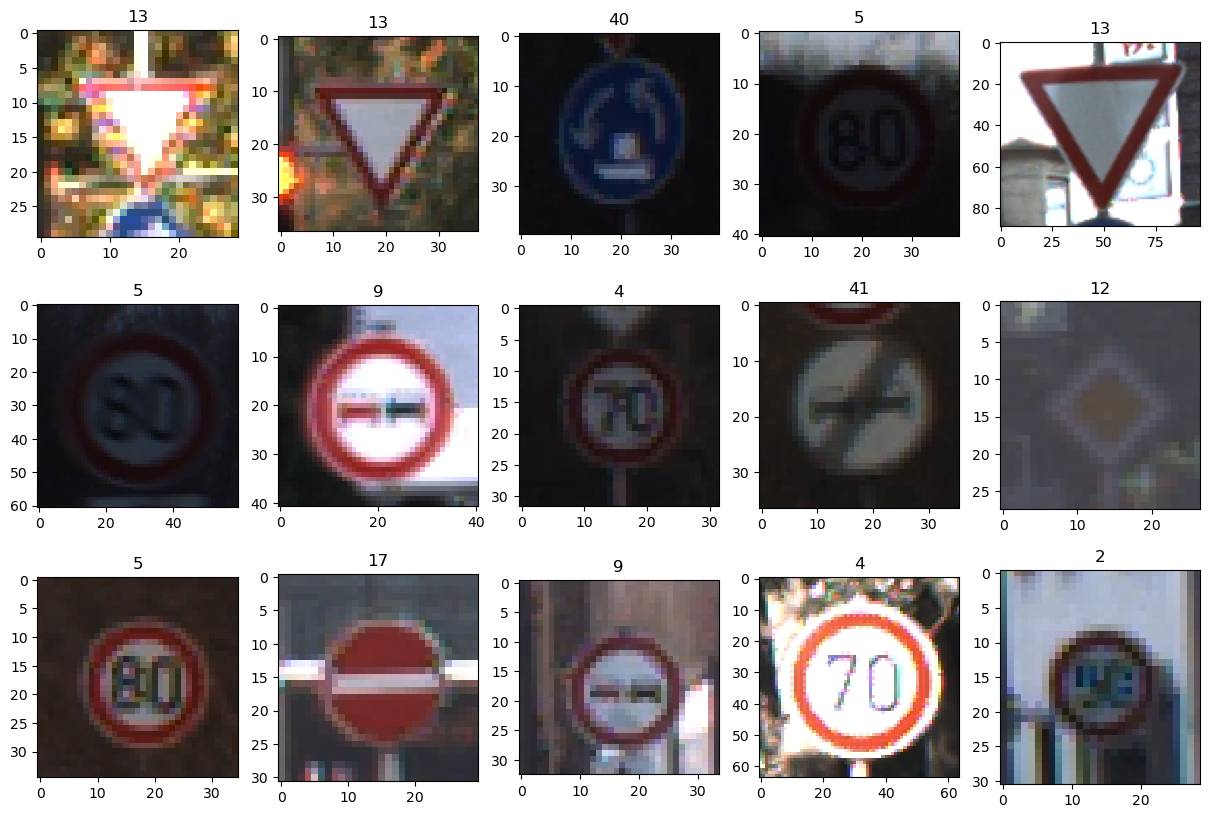

In [2]:

root = 'Downloads/archive' 
data = pd.read_csv(os.path.join(root, 'Train.csv'))

num_samples =len(data)

for ii in range(15):
    idx = np.random.randint(0, num_samples)
    img = cv2.imread(os.path.join(root, data.iloc[idx]['Path']))
    img = img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.subplot(3,5,ii+1), plt.imshow(img), plt.title(data.iloc[idx]['ClassId'])

(Text(0.5, 0, 'Traffic Sign ID'), Text(0, 0.5, 'Counts'))

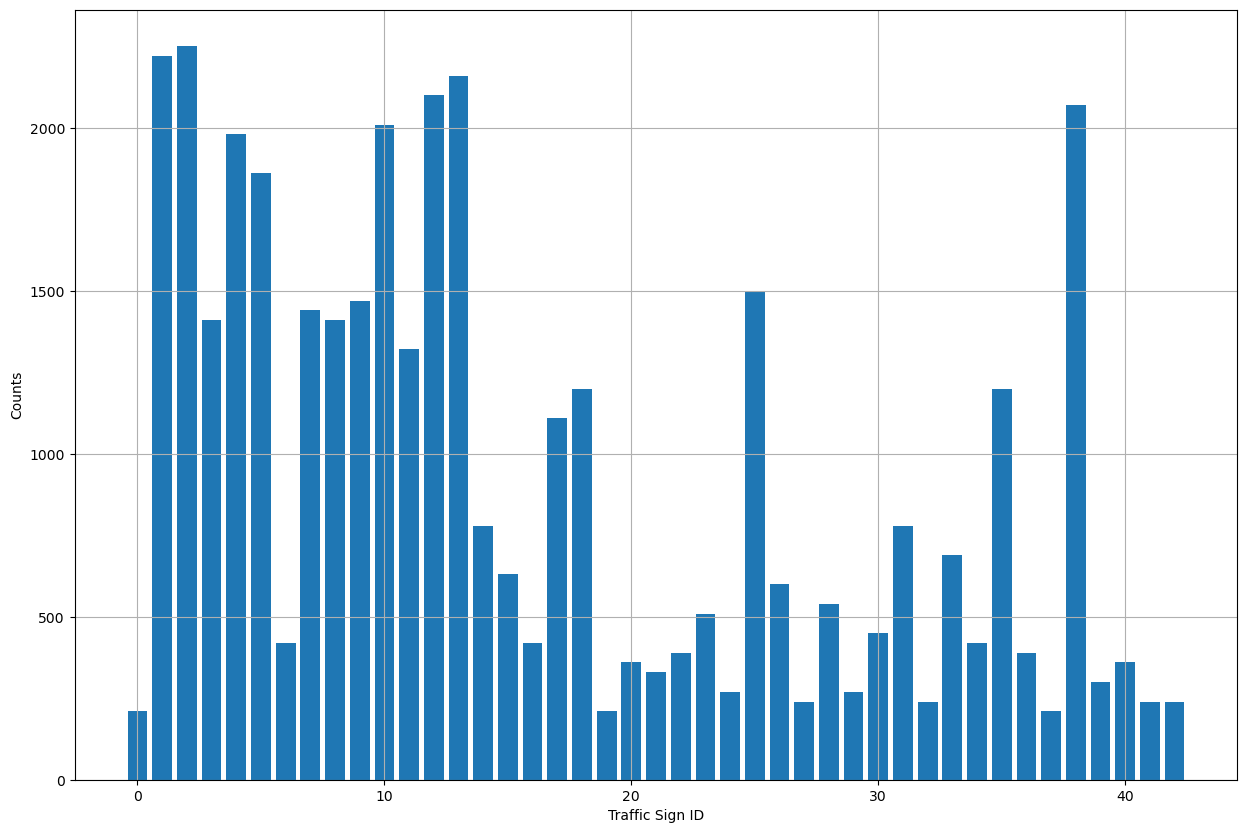

In [3]:
from collections import Counter
ids = data['ClassId']
hist = Counter(ids)
plt.bar(hist.keys(), hist.values()), plt.grid(True)
plt.xlabel('Traffic Sign ID'), plt.ylabel('Counts')

Min width: 25
Max width: 243
Min height: 25
Max height: 225
Mean width: 50.83587951745773
Mean height: 50.328929582493814


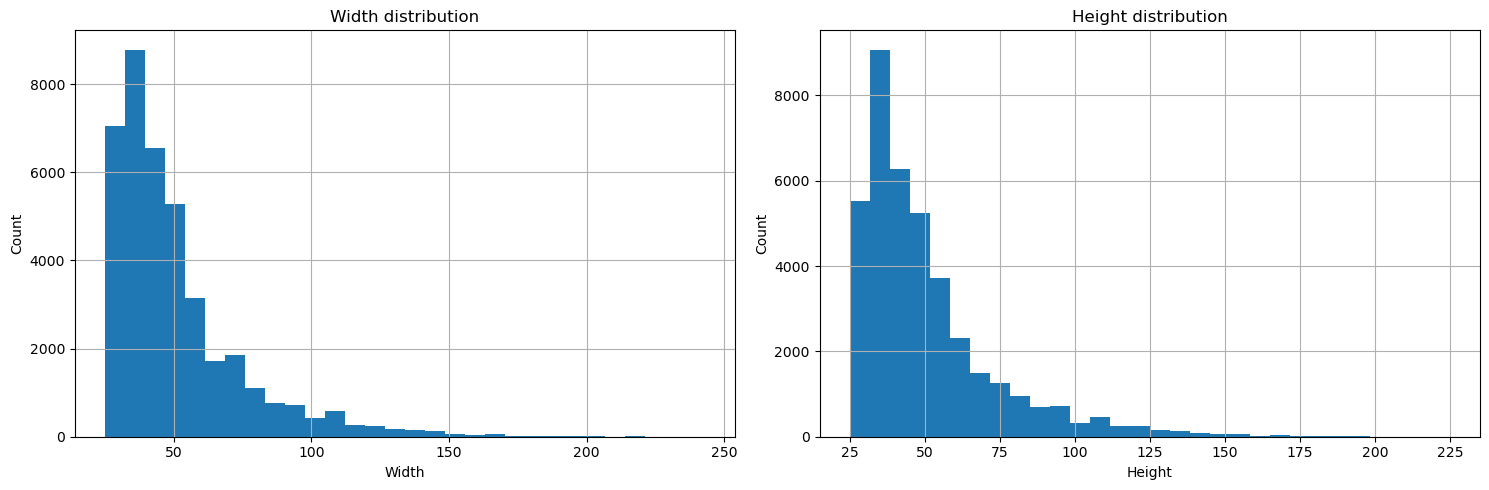

In [4]:
widths = data['Width']
heights = data['Height']

print("Min width:", widths.min())
print("Max width:", widths.max())
print("Min height:", heights.min())
print("Max height:", heights.max())
print("Mean width:", widths.mean())
print("Mean height:", heights.mean())

plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
plt.hist(widths, bins=30)
plt.xlabel('Width')
plt.ylabel('Count')
plt.title('Width distribution')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.hist(heights, bins=30)
plt.xlabel('Height')
plt.ylabel('Count')
plt.title('Height distribution')
plt.grid(True)

plt.tight_layout()
plt.show()

Min brightness: 6.202022777494475
Max brightness: 248.44000933706815
Mean brightness: 82.00611453570313


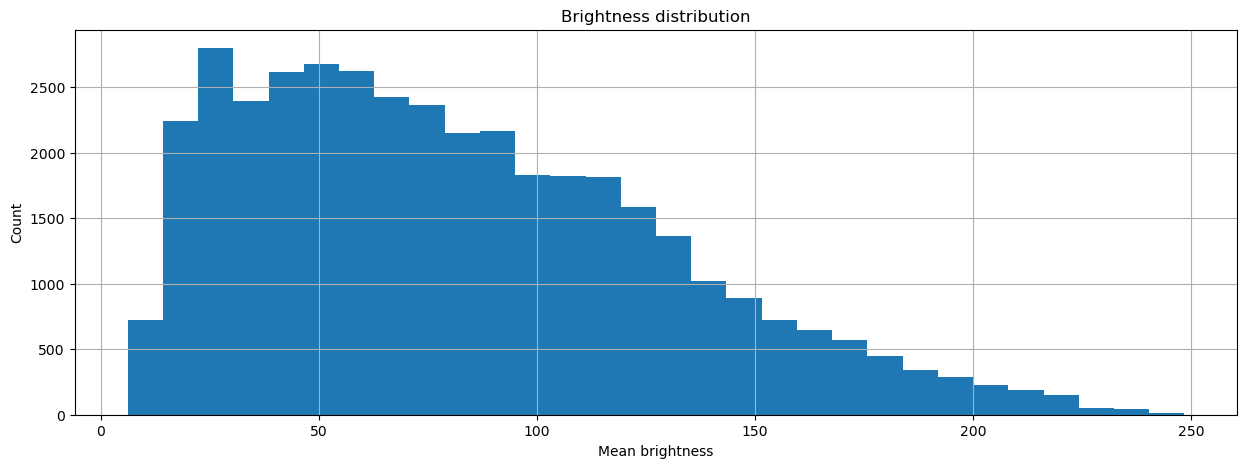

In [5]:
brightness = []
class_ids = []

for i in range(len(data)):
    img_path = os.path.join(root, data.iloc[i]['Path'])
    img = cv2.imread(img_path)
    
    # convert to grayscale
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    # mean brightness of image
    mean_brightness = np.mean(gray)
    
    brightness.append(mean_brightness)
    class_ids.append(data.iloc[i]['ClassId'])

brightness = np.array(brightness)
class_ids = np.array(class_ids)

print("Min brightness:", brightness.min())
print("Max brightness:", brightness.max())
print("Mean brightness:", brightness.mean())

plt.figure(figsize=(15, 5))
plt.hist(brightness, bins=30)
plt.xlabel('Mean brightness')
plt.ylabel('Count')
plt.title('Brightness distribution')
plt.grid(True)
plt.show()

In [ ]:
#1.No, the dataset is not balanced.he histogram shows that the number of samples is different across classes. Some traffic sign classes contain more than 2000 images, while others contain only a few hundred images.
#2.Yes, some classes such as 1, 2, 10, 12, 13,38 are over-represented, while classes such as 0, 29, 27, 26, 36, 40, 41, and 42 are under-represented.